# **Experiment Notebook**



In [95]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [96]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [97]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"

import pandas as pd

pd.__version__

'2.2.2'

---
## Student Information

In [98]:
# <Student to fill this section>
student_name = "Nishaanth Govindaraj"
student_id = "26044382"

In [99]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [100]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

In [101]:
# <Student to fill this section>
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import matplotlib.pyplot as plt
from joblib import dump
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score

from my_krml_26044382.data.weather import load_hourly_weather_years, aggregate_daily
from my_krml_26044382.data.sets import split_sets_by_time
from my_krml_26044382.features.targets import add_target_columns, create_future_targets, WHC_LABELS
from my_krml_26044382.features.build import build_features, get_feature_columns, REQUIRED_HISTORY_DAYS
from my_krml_26044382.models.performance import print_multiclass_scores

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## A. Project Description




In [102]:
# <Student to fill this section>
business_use_case_description = """
Open-Meteo is adding AI-powered weather intelligence services to its microservice platform. This project builds a
service that predicts the Weather Hazard Category (WHC) for Sydney exactly 7 days ahead. The category (Low,
Moderate, High or Extreme Risk) summarises how severe the weather will be for people, infrastructure and
transport, based on rain, wind gusts, cloud cover, snow and temperature extremes.

The service will be exposed through a REST API so that councils, transport operators, event organisers and
emergency planners get a one-week warning of potentially hazardous days.

Hypothesis for this experiment: a regularised multinomial logistic regression, trained with class weights on
today's weather, lagged values, rolling averages and seasonal features, predicts the WHC 7 days ahead better
(higher macro F1) than three simple baselines: always predicting the most common class, the most common class
for the month, and persistence (the category in 7 days equals today's category).
"""

In [103]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [104]:
# <Student to fill this section>
business_objectives = """
A reliable one-week hazard outlook lets organisations prepare in advance: scheduling maintenance crews,
adjusting transport timetables, securing outdoor events and informing the public.

Impact of accurate results: better preparedness, lower costs from disruption, safer events and more trust in
the Open-Meteo platform.

Impact of incorrect results:
- Missed hazards (forecasting Low or Moderate Risk when the day is High or Extreme): organisations are not
  prepared, which can lead to damage, disruption and safety risks. This is the most costly error.
- False alarms (forecasting High or Extreme Risk on a normal day): unnecessary preparation costs and, if
  repeated, users stop trusting the warnings.

Success criterion: the model must beat all three baselines on macro F1 on the validation set, and detect a
meaningful share of High and Extreme Risk days without an excessive number of false alarms.
"""

In [105]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [106]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Users of the predictions:
- Developers of apps and websites that consume the Open-Meteo API.
- Local councils, transport operators and utility companies planning operations and maintenance.
- Event organisers and emergency management teams preparing for severe weather.

People impacted by the predictions:
- The public, whose travel, work and safety may depend on preparation for hazardous days.
- Field staff and crews scheduled based on the outlook.
- The Open-Meteo business, whose reputation depends on the reliability of its warnings.

Expectations: the forecast must be available on demand through the API, easy to understand (4 named risk
levels), and transparent about its limits. A 7-day horizon is long for weather prediction, so the service is
expected to give an early indication of risk rather than a certain forecast.
"""

In [107]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Raw Data


In [108]:
# <Student to fill this section>
df_hourly = load_hourly_weather_years(2000, 2025, cache_dir='../../data/raw/yearly')
df_daily = aggregate_daily(df_hourly)

print(df_hourly.shape, df_daily.shape)
print(df_daily['date'].min(), df_daily['date'].max())

2000: loaded from cache
2001: loaded from cache
2002: loaded from cache
2003: loaded from cache
2004: loaded from cache
2005: loaded from cache
2006: loaded from cache
2007: loaded from cache
2008: loaded from cache
2009: loaded from cache
2010: loaded from cache
2011: loaded from cache
2012: loaded from cache
2013: loaded from cache
2014: loaded from cache
2015: loaded from cache
2016: loaded from cache
2017: loaded from cache
2018: loaded from cache
2019: loaded from cache
2020: loaded from cache
2021: loaded from cache
2022: loaded from cache
2023: loaded from cache
2024: loaded from cache
2025: loaded from cache
(227928, 13) (9497, 20)
2000-01-01 00:00:00 2025-12-31 00:00:00


### C.2 Define Target variable

In [109]:
# <Student to fill this section>
whi_inputs = ['precipitation', 'wind_gusts_10m', 'cloud_cover', 'snowfall', 'temperature_2m']
df_daily[whi_inputs].describe().T[['mean', 'min', 'max']]

,mean,min,max
precipitation,2.159324,0.000,138.400000
wind_gusts_10m,39.419196,12.600,102.200000
cloud_cover,47.379286,0.000,100.000000
snowfall,0.000000,0.000,0.000000
temperature_2m,17.475345,7.625,30.904167


In [110]:
# <Student to fill this section>
target_definition_explanations = """
The target is the Weather Hazard Category (WHC), derived from the Weather Hazard Index (WHI) defined by the
business: WHI = 100 x (0.30 RainHazard + 0.30 WindHazard + 0.20 CloudHazard + 0.10 SnowHazard + 0.10 TempHazard).
Each hazard score is between 0 and 1: rain reaches 1 at 30 mm per day, wind gusts at 100 km/h, cloud at 100
percent, snow at 15 cm, and the temperature hazard at 25 degC away from 22 degC.

The WHI is then converted into 4 classes: Low Risk (0, WHI below 25), Moderate Risk (1, 25 to 50),
High Risk (2, 50 to 75) and Extreme Risk (3, 75 and above). As required, the model predicts the class label,
not the continuous WHI.

Data granularity: hourly Open-Meteo observations for Sydney are aggregated to daily values as required: daily
total precipitation and snowfall, daily maximum wind gusts, and daily mean cloud cover and temperature.

Prediction target: the class exactly 7 days after day t, using only information available at the end of day t.
Only data up to 31 December 2025 is used. Data from 2026 onwards is reserved for production.
"""

In [111]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable



In [112]:
# <Student to fill this section>
df_daily = add_target_columns(df_daily)
df_daily = create_future_targets(df_daily, 'whc', 7)

target_name = 'whc'
target_col = 'whc_t_plus_7'
target_cols = [target_col]

df_daily[['date', 'whi', 'whc', target_col]].head(10)

,date,whi,whc,whc_t_plus_7
0,2000-01-01,35.383333,1,1
1,2000-01-02,30.421667,1,1
2,2000-01-03,21.736667,0,1
3,2000-01-04,29.360000,1,1
4,2000-01-05,22.138333,0,1
5,2000-01-06,23.303333,0,1
6,2000-01-07,29.730000,1,0
7,2000-01-08,28.086667,1,0
8,2000-01-09,27.863333,1,1
9,2000-01-10,27.686667,1,1


### C.4 Explore Target variable

           label  days  percent
0       Low Risk  5242     55.2
1  Moderate Risk  3970     41.8
2      High Risk   274     2.89
3   Extreme Risk    11     0.12


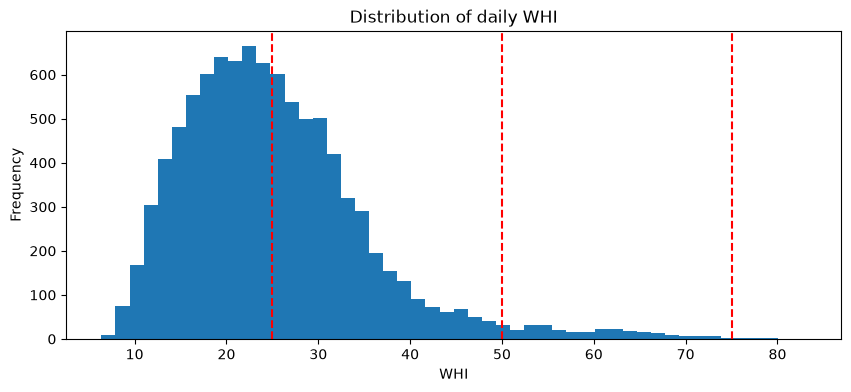

In [113]:
# <Student to fill this section>
whc_counts = df_daily['whc'].value_counts().reindex([0, 1, 2, 3], fill_value=0)
print(pd.DataFrame({'label': [WHC_LABELS[c] for c in whc_counts.index],
                    'days': whc_counts.values,
                    'percent': (whc_counts / whc_counts.sum() * 100).round(2).values}))

df_daily['whi'].plot(kind='hist', bins=50, figsize=(10, 4), title='Distribution of daily WHI')
for threshold in [25, 50, 75]:
    plt.axvline(threshold, color='red', linestyle='--')
plt.xlabel('WHI')
plt.show()

In [114]:
period = pd.cut(df_daily['date'].dt.year, bins=[1999, 2019, 2022, 2025],
                labels=['train 2000-2019', 'val 2020-2022', 'test 2023-2025'])
print(pd.crosstab(period, df_daily['whc'].map(WHC_LABELS)))

same_class = (df_daily['whc'] == df_daily[target_col]).mean()
print(f"\nShare of days where WHC(t+7) == WHC(t): {same_class:.3f}")

whc              Extreme Risk  High Risk  Low Risk  Moderate Risk
date                                                             
train 2000-2019             5        161      4242           2897
val 2020-2022               5         66       481            544
test 2023-2025              1         47       519            529

Share of days where WHC(t+7) == WHC(t): 0.501


In [115]:
# <Student to fill this section>
target_distribution_explanations = """
Distribution: the classes are heavily imbalanced. Out of 9,497 days, 5,242 are Low Risk (55.2 percent),
3,970 Moderate Risk (41.8 percent), 274 High Risk (2.9 percent) and only 11 Extreme Risk (0.12 percent).
A model that always predicts Low Risk would already be 55 percent accurate while being useless, so accuracy
cannot be the main metric.

Rare classes over time: Extreme Risk appears on 5 days in the training period (2000-2019), 5 in validation
(2020-2022) and only 1 in the test period (2023-2025). The model has almost no examples to learn this class,
and any score for it on validation or test is based on a handful of days.

Distribution shift: the class mix changes over time. Low Risk is the most common class in training (58 percent),
but from 2020 Moderate Risk is as common or more common, and High Risk days are 2 to 3 times more frequent
(2.2 percent in training, 6.0 percent in validation, 4.3 percent in test). 2020-2022 were La Nina years with
very wet conditions in Sydney.

Persistence: the class 7 days later equals today's class only about 50 percent of the time, which is worse than
always predicting Low Risk. Today's weather says little about the weather in a week, so most of the skill is
expected to come from seasonality and longer-term patterns.
"""

In [116]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `whi` (today's hazard level)

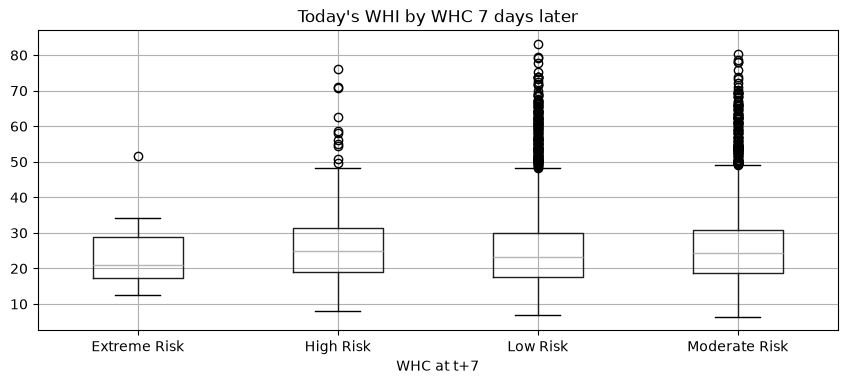

In [117]:
# <Student to fill this section>
df_plot = df_daily.dropna(subset=[target_col]).assign(whc_future=lambda d: d[target_col].astype(int).map(WHC_LABELS))
df_plot.boxplot(column='whi', by='whc_future', figsize=(10, 4))
plt.title("Today's WHI by WHC 7 days later")
plt.suptitle('')
plt.xlabel('WHC at t+7')
plt.show()

In [118]:
pd.crosstab(df_plot['whc'].map(WHC_LABELS), df_plot['whc_future'], normalize='index').round(3)

whc_future,Extreme Risk,High Risk,Low Risk,Moderate Risk
whc,,,,
Extreme Risk,0.000,0.091,0.455,0.455
High Risk,0.004,0.033,0.526,0.438
Low Risk,0.001,0.027,0.573,0.399
Moderate Risk,0.001,0.031,0.527,0.441


In [119]:
# <Student to fill this section>
feature_1_insights = """
Today's hazard level says very little about the hazard level 7 days later. The table shows the share of each
class at t+7 depending on today's class, and the rows are almost identical:
- after a Low Risk day: 57.3 percent Low, 39.9 percent Moderate, 2.7 percent High Risk a week later;
- after a Moderate Risk day: 52.7 percent Low, 44.1 percent Moderate, 3.1 percent High;
- after a High Risk day: 52.6 percent Low, 43.8 percent Moderate, 3.3 percent High.
Even after one of the 11 Extreme Risk days, 45.5 percent of the days a week later are Low Risk.

This matches the very weak correlation between today's WHI and the WHI 7 days later (0.063): the boxplot shows
largely overlapping distributions of today's WHI across the future classes. Storms and heavy rain events in
Sydney usually last one to three days, so they have ended by the forecast day. Longer rolling averages of WHI
are therefore used to capture persistent wet or stormy periods instead of single days.
"""

In [120]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `wind_gusts_10m`

whc_future      Extreme Risk  High Risk  Low Risk  Moderate Risk
wind_gusts_10m                                                  
(12.599, 28.8]         0.002      0.020     0.644          0.334
(28.8, 35.6]           0.001      0.033     0.545          0.421
(35.6, 41.4]           0.000      0.027     0.530          0.442
(41.4, 49.0]           0.001      0.031     0.504          0.465
(49.0, 102.2]          0.002      0.034     0.535          0.430


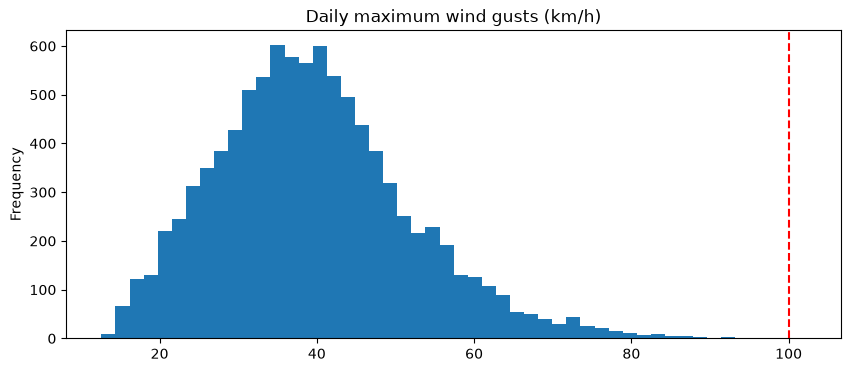

In [121]:
# <Student to fill this section>
gust_bins = pd.qcut(df_plot['wind_gusts_10m'], q=5)
print(pd.crosstab(gust_bins, df_plot['whc_future'], normalize='index').round(3))

df_daily['wind_gusts_10m'].plot(kind='hist', bins=50, figsize=(10, 4), title='Daily maximum wind gusts (km/h)')
plt.axvline(100, color='red', linestyle='--')
plt.show()

In [122]:
# <Student to fill this section>
feature_2_insights = """
Daily maximum gusts range from 12.6 to 102.2 km/h. The histogram is right-skewed: most days have gusts between
25 and 50 km/h (peak around 35-40 km/h), and only a few days exceed 80 km/h. Gusts reach the maximum wind hazard
of 100 km/h almost never, so the wind component rarely contributes its full 30 points to the WHI.

The table splits today's gusts into 5 equal groups and shows the class 7 days later. The calmest days (below
28.8 km/h) are followed by more Low Risk days (64.4 percent) and fewer High Risk days (2.0 percent) than the
other groups (50-55 percent Low, 2.7-3.4 percent High). Above 28.8 km/h, the shares barely change with the
gust level.

Wind has a same-day correlation of 0.476 with the WHI, but today's gusts carry little information about gusts
a week later, since wind is driven by passing weather systems. The small difference for calm days is likely a
seasonal effect (calm days are more common in the cooler, lower-risk months) rather than a direct wind effect.
"""

In [123]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `month` (seasonality)

In [124]:
# <Student to fill this section>
month_mix = pd.crosstab(df_plot['date'].dt.month, df_plot['whc_future'], normalize='index').round(3)
month_mix

whc_future,Extreme Risk,High Risk,Low Risk,Moderate Risk
date,,,,
1,0.000,0.037,0.457,0.506
2,0.001,0.042,0.456,0.501
3,0.001,0.045,0.576,0.378
4,0.001,0.021,0.674,0.304
5,0.001,0.032,0.644,0.323
6,0.005,0.018,0.623,0.354
7,0.001,0.016,0.658,0.325
8,0.001,0.026,0.609,0.364
9,0.000,0.017,0.612,0.372


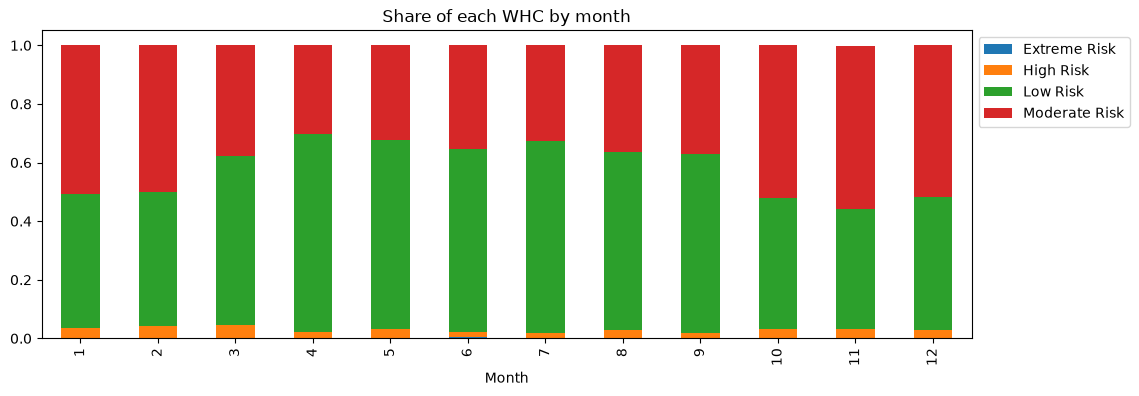

In [125]:
month_mix.plot(kind='bar', stacked=True, figsize=(12, 4), title='Share of each WHC by month')
plt.xlabel('Month')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [126]:
# <Student to fill this section>
feature_n_insights = """
The class mix changes clearly with the season:
- Warm season (October to March) is the most hazardous: Moderate Risk is the most common class from October to
  February (50 to 56 percent), and High Risk is most frequent in February and March (4.2 and 4.5 percent),
  when summer storms and heavy rain are common.
- Cool season (April to September) is mostly Low Risk (61 to 67 percent), with fewer High Risk days
  (1.6 to 3.2 percent).
- Extreme Risk is very rare in every month. Its highest share is in June (0.5 percent), which is consistent with
  winter coastal storm systems affecting Sydney.

Because the hazard 7 days ahead is hard to predict from today's weather, the season is likely to be one of the
most useful signals. It is captured in the model through the month and the cyclical day-of-year features
(doy_sin, doy_cos), and it is the basis of the monthly baseline.
"""

In [127]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection



### D.1 Approach "Correlation with the WHI 7 days later (training years only)"

In [128]:
# <Student to fill this section>
# The continuous WHI 7 days later is used here only to measure relationships (it is not a model feature)
whi_future = df_daily['whi'].shift(-7)
train_period = df_daily['date'] < '2020-01-01'
base_cols = [c for c in df_daily.columns if c not in ['date', 'whc'] + target_cols]

corr_whi_future = (df_daily.loc[train_period, base_cols]
                   .corrwith(whi_future[train_period])
                   .sort_values(key=abs, ascending=False))
corr_whi_future.round(3)

temperature_2m              0.140
shortwave_radiation         0.137
apparent_temperature        0.133
temperature_2m_min          0.130
temperature_2m_max          0.127
dew_point_2m                0.114
wind_gusts_10m              0.080
wind_speed_10m_max          0.073
cci                         0.056
pressure_msl               -0.047
pressure_msl_min           -0.045
wind_speed_10m              0.045
cloud_cover                 0.041
whi                         0.040
relative_humidity_2m_max    0.037
cloud_cover_max             0.036
rain                        0.011
precipitation               0.011
precipitation_hours         0.009
relative_humidity_2m        0.009
snowfall                      NaN
dtype: float64

In [129]:
# <Student to fill this section>
feature_selection_1_insights = """
The correlation between each daily variable and the WHI 7 days later was calculated on the training years only
(2000-2019), so the validation and test periods do not influence the selection. The continuous WHI is used here
because a correlation with a 4-class label is hard to interpret.

All correlations are weak (below 0.15). The strongest are temperature (0.140), solar radiation (0.137), apparent
temperature (0.133) and minimum and maximum temperature (0.130 and 0.127). These are mainly seasonal signals:
warm, sunny days occur in the warmer months, which are the most hazardous (Section C.7).

Today's hazard ingredients are almost unrelated to the hazard in a week: wind gusts 0.080, cloud cover 0.041,
today's WHI 0.040 and precipitation only 0.011. This confirms that the forecast will have to rely on seasonal
and longer-term patterns rather than today's weather.

No variable was removed on correlation alone: weak linear correlations do not mean a variable is useless, and
the model's regularisation reduces the influence of unhelpful features automatically.
"""

In [130]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Remove constant and duplicate variables"

In [131]:
# <Student to fill this section>
print(df_daily[['snowfall', 'rain', 'precipitation']].describe().T[['mean', 'std', 'max']])
print("rain identical to precipitation:", np.allclose(df_daily['rain'], df_daily['precipitation']))

                   mean       std    max
snowfall       0.000000  0.000000    0.0
rain           2.159324  6.148343  138.4
precipitation  2.159324  6.148343  138.4
rain identical to precipitation: True


In [132]:
# <Student to fill this section>
feature_selection_2_insights = """
snowfall is always 0 in Sydney (standard deviation 0). A constant variable carries no information, so it is
removed from the features. It is still used inside the WHI formula as required (10 percent weight), but always
contributes 0 there, so in practice the maximum WHI in Sydney is 90.

rain is identical to precipitation, because all precipitation in Sydney falls as rain. Keeping both would give
the model the same information twice and make its coefficients unstable, so rain is removed and precipitation
is kept.
"""

In [133]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features



In [134]:
# <Student to fill this section>

features_list = [c for c in base_cols if c not in ['snowfall', 'rain']]
print(len(features_list))
features_list

19


['temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'cloud_cover',
 'precipitation',
 'wind_gusts_10m',
 'temperature_2m_max',
 'temperature_2m_min',
 'relative_humidity_2m_max',
 'wind_speed_10m_max',
 'cloud_cover_max',
 'precipitation_hours',
 'dew_point_2m',
 'apparent_temperature',
 'pressure_msl',
 'pressure_msl_min',
 'shortwave_radiation',
 'cci',
 'whi']

In [135]:
# <Student to fill this section>
feature_selection_explanations = """
The 19 base daily variables kept are: the 5 CCI inputs (temperature, humidity, wind speed, cloud cover,
precipitation), wind gusts, daily min and max temperature, max humidity, max wind speed, max cloud cover,
precipitation hours, dew point, apparent temperature, mean and min sea-level pressure, solar radiation, and
today's CCI and WHI.

Section F adds engineered features built from these base variables (lags, rolling windows, pressure change,
calendar features), giving the final feature set used for modelling.
"""

In [136]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation `Missing days and values check`

In [137]:
# <Student to fill this section>
full_range = pd.date_range(df_daily['date'].min(), df_daily['date'].max(), freq='D')
print(f"Missing days: {len(full_range.difference(df_daily['date']))}")
print(f"Missing values in base features: {df_daily[features_list].isna().sum().sum()}")

Missing days: 0
Missing values in base features: 0


In [138]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Lag, rolling and future-target features are created by shifting rows, so every row must be exactly one day
apart. A missing day would silently misalign features and targets (e.g. a lag-1 value coming from two days
before). The check confirms 0 missing days and 0 missing values across 9,497 days, so no imputation is needed.
The build_features function also enforces one row per calendar day as a safeguard.
"""

In [139]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation `Exclude production data (2026 onwards)`

In [140]:
# <Student to fill this section>
assert df_daily['date'].max() <= pd.Timestamp('2025-12-31')
print("No 2026 data in the experiment dataset")

No 2026 data in the experiment dataset


In [141]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Data from 2026 onwards represents production data and must not be accessible during the project. Only data
up to 31 December 2025 was downloaded, and this check guarantees it. The target for the last 7 days of 2025
would need 2026 values, so those rows have a missing target and are removed before modelling.
"""

In [142]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation `Physical range check`

In [143]:
# <Student to fill this section>
df_daily[features_list].describe().T[['min', 'max']]

,min,max
temperature_2m,7.625000,30.904167
relative_humidity_2m,23.875000,96.041667
wind_speed_10m,3.308333,37.387500
cloud_cover,0.000000,100.000000
precipitation,0.000000,138.400000
wind_gusts_10m,12.600000,102.200000
temperature_2m_max,10.000000,42.000000
temperature_2m_min,1.100000,27.100000
relative_humidity_2m_max,34.000000,100.000000
wind_speed_10m_max,5.100000,48.800000


In [144]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Each variable was checked against physically plausible ranges. All values are plausible for Sydney: humidity
between 24 and 96 percent (daily mean), cloud cover between 0 and 100 percent, no negative precipitation or
wind speed, daily mean temperature between 7.6 and 30.9 degC (maximum 42.0 degC on heatwave days), sea-level
pressure between 991.5 and 1037.7 hPa, and wind gusts up to 102.2 km/h.

The largest daily rainfall (138.4 mm) and the strongest gusts are extreme but realistic storm events. They are
exactly the days that define the High and Extreme Risk classes, so no outlier removal was applied.
"""

In [145]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Lag, rolling and calendar features (build_features)"

In [146]:
# <Student to fill this section>
df_features = build_features(df_daily)
feature_cols = get_feature_columns(df_features)

print(df_features.shape)
print(f"{len(feature_cols)} features")

(9497, 94)
92 features


In [147]:
# <Student to fill this section>
feature_engineering_1_explanations = """
All engineered features are created by build_features() from the custom package (my_krml_26044382 v0.0.5).
The same function is used by the deployed API, so production features are guaranteed to match training.

Features created (all use only information available at the end of day t, so there is no leakage):
- Lags of 1, 2, 3 and 7 days for CCI, WHI, temperature, humidity, precipitation, cloud cover, wind speed,
  wind gusts and pressure.
- Rolling means over 3, 7, 14 and 30 days for CCI, WHI, temperature, humidity, cloud cover and wind gusts.
- Rolling rainfall totals over 3, 7, 14 and 30 days.
- Calendar features: month, day of year, day of week and a cyclical encoding (sin and cos of day of year), so
  that 31 December and 1 January are close to each other.
- Daily temperature range and 1-day and 3-day pressure change (Section F.2).

The first 29 days of 2000 lack a complete 30-day history and are removed before modelling.
"""

In [148]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "Pressure change"

In [149]:
# <Student to fill this section>
whi_future_features = df_features['whi'].shift(-7)
pressure_cols = ['pressure_msl_change_1d', 'pressure_msl_change_3d']
print(df_features[pressure_cols].describe().round(2))
print(df_features[pressure_cols].corrwith(whi_future_features).round(3))

       pressure_msl_change_1d  pressure_msl_change_3d
count                 9496.00                 9494.00
mean                    -0.00                   -0.00
std                      4.43                    7.90
min                    -17.08                  -31.50
25%                     -2.99                   -5.41
50%                     -0.16                   -0.22
75%                      2.88                    5.22
max                     17.99                   33.80
pressure_msl_change_1d    0.008
pressure_msl_change_3d    0.008
dtype: float64


In [150]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The change in sea-level pressure over 1 and 3 days is a classic forecasting signal: falling pressure usually
indicates an approaching front or low-pressure system bringing cloud, wind and rain. Its standard deviation is
4.4 hPa over 1 day and 7.9 hPa over 3 days.

Correlation with the WHI 7 days later: 0.008 for both the 1-day and 3-day change, meaning no linear
relationship at all. This is expected: a pressure trend announces weather for the next 1 to 3 days, and the
system has usually passed a week later. The features are kept because they are needed for the CCI models,
cost nothing, and can be ignored by the model.
"""

In [151]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "Lag and rolling window signals"

In [152]:
# <Student to fill this section>
lag_roll = ['whi', 'whi_lag_7', 'whi_roll7_mean', 'whi_roll30_mean', 'precipitation_roll30_sum',
            'cloud_cover_roll30_mean', 'doy_cos', 'doy_sin']
df_features[lag_roll].corrwith(whi_future_features).round(3)

whi                         0.063
whi_lag_7                   0.054
whi_roll7_mean              0.105
whi_roll30_mean             0.141
precipitation_roll30_sum    0.058
cloud_cover_roll30_mean     0.088
doy_cos                     0.173
doy_sin                    -0.041
dtype: float64

In [153]:
# <Student to fill this section>
feature_engineering_n_explanations = """
This compares how strongly each lag, rolling and seasonal feature relates to the WHI 7 days later:
- The seasonal encoding doy_cos is the strongest (0.173).
- Longer windows beat single days: the 30-day rolling mean of WHI (0.141) is more than twice as strong as
  today's WHI (0.063), followed by the 7-day mean (0.105) and the 30-day mean of cloud cover (0.088).
- The value from 7 days before (whi_lag_7, 0.054) and the 30-day rainfall total (0.058) are weak.

As expected for a 7-day horizon, features describing the current season and weather regime (e.g. a wet month)
are more useful than the weather of a single day, but all relationships remain weak.
"""

In [154]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Data Preparation for Modeling



### G.1 Split Datasets

In [155]:
# <Student to fill this section>
df_model = df_features.dropna(subset=feature_cols + target_cols).reset_index(drop=True)
df_model[target_col] = df_model[target_col].astype(int)

X_train, y_train, X_val, y_val, X_test, y_test = split_sets_by_time(
    df_model[feature_cols], df_model[target_col], df_model['date'],
    val_start='2020-01-01', test_start='2023-01-01', gap=7
)

for name, X, y in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
    d = df_model.loc[X.index, 'date']
    counts = y.value_counts().reindex([0, 1, 2, 3], fill_value=0).tolist()
    print(f"{name}: {len(X)} rows, {d.min().date()} to {d.max().date()}, class counts {counts}")

train: 7269 rows, 2000-01-30 to 2019-12-24, class counts [4226, 2878, 160, 5]
val: 1089 rows, 2020-01-01 to 2022-12-24, class counts [480, 538, 66, 5]
test: 1089 rows, 2023-01-01 to 2025-12-24, class counts [516, 528, 44, 1]


In [156]:
# <Student to fill this section>
data_splitting_explanations = """
A chronological split is used instead of a random split. With time series, a random split would put days from
the future in the training set and neighbouring, highly correlated days in both training and validation, which
leaks information and gives overly optimistic results. A stratified random split is also not possible, for the
same reason.

- Training: 30 Jan 2000 to 24 Dec 2019 (20 years)
- Validation: 2020 to 2022 (used to compare models and tune hyperparameters)
- Testing: 2023 to 2025 (kept untouched until the final model is chosen)

A 7-day gap is removed at the end of the training and validation periods. Without it, the targets of the last
training days (the category 7 days later) would come from validation days.

Because of the rare classes, each set contains very few High and especially Extreme Risk days (see the class
counts above), so their per-class scores must be interpreted with caution.
"""

In [157]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Standard scaling"

In [158]:
# <Student to fill this section>
X_train[['pressure_msl', 'precipitation', 'doy_sin']].describe().loc[['mean', 'std']].round(2)

,pressure_msl,precipitation,doy_sin
mean,1017.20,1.81,-0.00
std,6.67,5.32,0.71


In [159]:
# <Student to fill this section>
data_transformation_1_explanations = """
The features are on very different scales (pressure around 1015 hPa, precipitation mostly 0 to 20 mm, cyclical
features between -1 and 1). Logistic regression with regularisation penalises the size of the coefficients, so
without scaling the penalty would affect features unequally, and the solver would also converge more slowly.
A StandardScaler is therefore applied (mean 0, standard deviation 1).

The scaler is placed inside a scikit-learn Pipeline with the model (Section J). It is fitted on the training
set only and then applied to validation and test data, which avoids leakage, and it is saved together with the
model so the API applies exactly the same transformation.
"""

In [160]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "Categorical encoding (not required)"

In [161]:
# <Student to fill this section>
non_numeric = X_train.select_dtypes(exclude='number').columns.tolist()
print(f"Non-numeric features: {non_numeric}")

Non-numeric features: []


In [162]:
# <Student to fill this section>
data_transformation_2_explanations = """
All features are numeric, including the calendar features and today's hazard class (whc, an ordered value from
0 to 3), so no categorical encoding is required. The month is kept as a number because the cyclical features
doy_sin and doy_cos already represent the seasonal cycle smoothly.
"""

In [163]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "Missing value imputation (not required)"

In [164]:
# <Student to fill this section>
print(f"Missing values - train: {X_train.isna().sum().sum()}, val: {X_val.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")

Missing values - train: 0, val: 0, test: 0


In [165]:
# <Student to fill this section>
data_transformation_3_explanations = """
No imputation is required. The raw data has no missing days or values, and the only missing values created by
feature engineering (the first 29 days without a full 30-day history) and by the target (the last 7 days of
2025) were removed before splitting. Removing them is preferable to imputing, because an imputed lag or target
would be invented data.
"""

In [166]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

In [167]:
# <Student to fill this section>

data_final_path = '../../data/processed/whc_exp1'
os.makedirs(data_final_path, exist_ok=True)

In [168]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(f'{data_final_path}/X_train.csv', index=False)
  y_train.to_csv(f'{data_final_path}/y_train.csv', index=False)

  X_val.to_csv(f'{data_final_path}/X_val.csv', index=False)
  y_val.to_csv(f'{data_final_path}/y_val.csv', index=False)

  X_test.to_csv(f'{data_final_path}/X_test.csv', index=False)
  y_test.to_csv(f'{data_final_path}/y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate




In [169]:
# <Student to fill this section>
CLASS_LABELS = [0, 1, 2, 3]

def evaluate_classifier(y_true, y_pred, set_name):
    """Print accuracy and F1 scores, and return them with per-class recall and hazard metrics"""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    scores = print_multiclass_scores(y_pred, y_true, set_name)
    recalls = recall_score(y_true, y_pred, labels=CLASS_LABELS, average=None, zero_division=0)
    for c, r in zip(CLASS_LABELS, recalls):
        scores[f'recall_{WHC_LABELS[c]}'] = float(r)
    hazardous = y_true >= 2
    alerts = y_pred >= 2
    scores['hazard_days'] = int(hazardous.sum())
    scores['hazard_recall'] = float((y_pred[hazardous] >= 2).mean()) if hazardous.any() else float('nan')
    scores['alerts'] = int(alerts.sum())
    scores['false_alarm_rate'] = float((y_true[alerts] <= 1).mean()) if alerts.any() else float('nan')
    return scores

dates_val = df_model.loc[X_val.index, 'date']
train_dates = df_model.loc[X_train.index, 'date']

# Baseline 1: always the most common class in training
majority_class = int(y_train.mode()[0])
# Baseline 2: most common class in training for the month of the target day
monthly_mode = y_train.groupby((train_dates + pd.to_timedelta(7, unit='D')).dt.month).agg(lambda s: s.mode()[0])
# Baseline 3: persistence (the class in 7 days equals today's class)

baseline_preds = {
    'majority': np.full(len(y_val), majority_class),
    'monthly_mode': (dates_val + pd.to_timedelta(7, unit='D')).dt.month.map(monthly_mode).values,
    'persistence': X_val['whc'].values,
}

baseline_scores = {}
for name, pred in baseline_preds.items():
    print(f"\n--- {name} ---")
    baseline_scores[name] = evaluate_classifier(y_val, pred, f'Val {name}')

pd.DataFrame(baseline_scores).T[['accuracy', 'f1_macro', 'hazard_recall', 'false_alarm_rate']].round(3)


--- majority ---
Accuracy Val majority: 0.4408
F1 Macro Val majority: 0.1530
F1 Weighted Val majority: 0.2697

--- monthly_mode ---
Accuracy Val monthly_mode: 0.4812
F1 Macro Val monthly_mode: 0.2256
F1 Weighted Val monthly_mode: 0.4141

--- persistence ---
Accuracy Val persistence: 0.4426
F1 Macro Val persistence: 0.2526
F1 Weighted Val persistence: 0.4425


,accuracy,f1_macro,hazard_recall,false_alarm_rate
majority,0.441,0.153,0.000,NaN
monthly_mode,0.481,0.226,0.000,NaN
persistence,0.443,0.253,0.085,0.915


In [170]:
# <Student to fill this section>
performance_metrics_explanations = """
Because the classes are heavily imbalanced, accuracy is misleading. The metrics used are:
- Macro F1 (main metric): the average F1 score of the classes, giving the same weight to each class, so rare
  hazardous classes count as much as common ones.
- Recall per class: the share of each class correctly detected.
- Hazard recall (business metric): the share of High or Extreme Risk days forecast as High or Extreme Risk.
- False alarm rate (business metric): the share of High or Extreme Risk forecasts that turn out Low or
  Moderate Risk.
- Accuracy and weighted F1 are reported for completeness.

Baselines on the validation set (2020-2022):
- Majority (always Low Risk): accuracy 0.441, macro F1 0.153, hazard recall 0.
- Monthly mode (most common class for the month): accuracy 0.481, macro F1 0.226, hazard recall 0.
- Persistence (today's class): accuracy 0.443, macro F1 0.253, hazard recall 0.085 with a false alarm rate
  of 0.915.

The majority class is only 44 percent accurate on validation, compared with 58 percent Low Risk days in training.
This shows the distribution shift: in 2020-2022 Moderate Risk was more common than Low Risk (538 vs 480 days),
and there were 66 High and 5 Extreme Risk days.
"""

In [171]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [172]:
# <Student to fill this section>
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [173]:
# <Student to fill this section>
algorithm_selection_explanations = """
Multinomial logistic regression is used as the first experiment because it is simple, fast and interpretable:
it estimates the probability of each class, and its coefficients show how each feature pushes the forecast
towards each risk level. It sets a transparent benchmark before trying more complex models.

It supports class weights, which increase the importance of the rare High and Extreme Risk days during training.
Without them, the model would mostly predict Low and Moderate Risk, since these make up 97 percent of the days.

Its limitation is that it only learns linear decision boundaries. Experiment 2 (XGBoost) will test whether a
non-linear model does better.
"""

In [174]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [175]:
# <Student to fill this section>
C_values = [0.001, 0.01, 0.1, 1, 10]
class_weight_options = [None, 'balanced']

tuning_results = []
for class_weight in class_weight_options:
    for C in C_values:
        pipe = Pipeline([('scaler', StandardScaler()),
                         ('logreg', LogisticRegression(C=C, class_weight=class_weight, max_iter=3000))])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_val)
        hazardous = y_val.values >= 2
        tuning_results.append({
            'class_weight': str(class_weight), 'C': C,
            'val_f1_macro': f1_score(y_val, pred, average='macro', zero_division=0),
            'val_hazard_recall': (pred[hazardous] >= 2).mean(),
        })

tuning_results = pd.DataFrame(tuning_results)
print(tuning_results.pivot(index='C', columns='class_weight', values=['val_f1_macro', 'val_hazard_recall']).round(3))

best = tuning_results.loc[tuning_results['val_f1_macro'].idxmax()]
best_C = float(best['C'])
best_class_weight = None if best['class_weight'] == 'None' else best['class_weight']
print(f"\nBest: C={best_C}, class_weight={best_class_weight}")

             val_f1_macro          val_hazard_recall         
class_weight         None balanced              None balanced
C                                                            
0.001               0.241    0.209               0.0    0.380
0.010               0.250    0.223               0.0    0.310
0.100               0.250    0.225               0.0    0.282
1.000               0.248    0.245               0.0    0.268
10.000              0.251    0.242               0.0    0.239

Best: C=10.0, class_weight=None


In [176]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Two hyperparameters were tuned using the validation macro F1:
- C (0.001 to 10): the inverse of the regularisation strength. A small C strongly shrinks the coefficients
  (simpler model, less overfitting); a large C lets the model fit the training data more closely.
- class_weight (None or balanced): balanced weights each class inversely to its frequency, so the rare High and
  Extreme Risk days have much more influence during training.

Best settings by macro F1: C = 10 without class weights (macro F1 0.251). The results are flat: all models
without weights score between 0.241 and 0.251.

The class weights reveal a trade-off. Without weights, the model never forecasts a hazardous day (hazard recall
0 for every C). With balanced weights, it detects 24 to 38 percent of hazardous days (38 percent with C = 0.001),
but its macro F1 is lower (0.209 to 0.245), because the extra High Risk forecasts include many false alarms
that reduce the scores of the Low and Moderate classes. Selecting by macro F1 alone therefore favours the model
that ignores hazards, which conflicts with the business goal.
"""

In [177]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [178]:
# <Student to fill this section>
model = Pipeline([('scaler', StandardScaler()),
                  ('logreg', LogisticRegression(C=best_C, class_weight=best_class_weight, max_iter=3000))])
model.fit(X_train, y_train)

os.makedirs('../../models/weather_hazard', exist_ok=True)
dump(model, '../../models/weather_hazard/whc_exp1_logreg.joblib')

['../../models/weather_hazard/whc_exp1_logreg.joblib']

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [179]:
# <Student to fill this section>
print("===== Training =====")
evaluate_classifier(y_train, model.predict(X_train), 'Training')
print("\n===== Validation =====")
val_pred = model.predict(X_val)
val_scores = evaluate_classifier(y_val, val_pred, 'Validation')

results = pd.DataFrame({'LogisticRegression': val_scores, **baseline_scores}).T
os.makedirs('../../reports', exist_ok=True)
results.to_csv('../../reports/whc_exp1_results.csv')

print("\nValidation comparison:")
print(results[['accuracy', 'f1_macro', 'recall_Low Risk', 'recall_Moderate Risk', 'recall_High Risk',
               'recall_Extreme Risk', 'hazard_recall', 'false_alarm_rate']].round(3))

print("\nConfusion matrix (validation, rows = actual, columns = predicted):")
labels = [WHC_LABELS[c] for c in CLASS_LABELS]
print(pd.DataFrame(confusion_matrix(y_val, val_pred, labels=CLASS_LABELS), index=labels, columns=labels))

print("\nClassification report (validation):")
print(classification_report(y_val, val_pred, labels=CLASS_LABELS, target_names=labels, zero_division=0))

logreg = model.named_steps['logreg']
if 2 in logreg.classes_:
    coef_high = pd.Series(logreg.coef_[list(logreg.classes_).index(2)], index=feature_cols)
    print("Top 10 coefficients pushing towards High Risk:")
    print(coef_high.reindex(coef_high.abs().sort_values(ascending=False).index).head(10).round(3))

===== Training =====
Accuracy Training: 0.6156
F1 Macro Training: 0.4271
F1 Weighted Training: 0.5837

===== Validation =====
Accuracy Validation: 0.5060
F1 Macro Validation: 0.2515
F1 Weighted Validation: 0.4653

Validation comparison:
                    accuracy  f1_macro  recall_Low Risk  recall_Moderate Risk  \
LogisticRegression     0.506     0.251            0.802                 0.309   
majority               0.441     0.153            1.000                 0.000   
monthly_mode           0.481     0.226            0.862                 0.204   
persistence            0.443     0.253            0.444                 0.491   

                    recall_High Risk  recall_Extreme Risk  hazard_recall  \
LogisticRegression             0.000                  0.0          0.000   
majority                       0.000                  0.0          0.000   
monthly_mode                   0.000                  0.0          0.000   
persistence                    0.076                 

In [180]:
# <Student to fill this section>
model_performance_explanations = """
Validation results (2020-2022): accuracy 0.506 and macro F1 0.251. The model beats the majority baseline
(0.153) and the monthly baseline (0.226), but not persistence (0.253).

Per class, the model mostly separates Low from Moderate Risk: it detects 80.2 percent of Low Risk days but only
30.9 percent of Moderate Risk days, and none of the 66 High or 5 Extreme Risk days. The confusion matrix shows
two main problems:
- Distribution shift: 369 of the 538 Moderate Risk days are forecast as Low Risk. The model learned from
  2000-2019, when Low Risk dominated, and keeps forecasting it in the wetter 2020-2022 period.
- No hazard detection: the model forecast High Risk only 5 times, and all 5 were wrong, while all 71 hazardous
  days were forecast as Low or Moderate Risk.

Training vs validation: macro F1 falls from 0.427 in training to 0.251 in validation, caused by overfitting
(the weakest regularisation, C = 10, was selected) and by the distribution shift.

Coefficients: the largest coefficients for High Risk come in pairs of correlated features with opposite signs
(e.g. temperature -1.57 and apparent temperature +1.31, cci_roll14_mean +1.47 and cci_roll30_mean -1.25). This
is a sign of multicollinearity with weak regularisation, so the individual coefficients cannot be interpreted
reliably. Overall, the most influential features are temperature, seasonal and long rolling-window features,
consistent with the correlation analysis.
"""

In [181]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [182]:
# <Student to fill this section>
n_years_val = len(y_val) / 365.25
alerts = val_pred >= 2
hazardous = y_val.values >= 2
business = pd.DataFrame({
    'LogisticRegression': {
        'hazardous_days_per_year': hazardous.sum() / n_years_val,
        'alerts_per_year': alerts.sum() / n_years_val,
        'hazards_detected': int((alerts & hazardous).sum()),
        'hazards_missed': int((~alerts & hazardous).sum()),
        'false_alarms': int((alerts & ~hazardous).sum()),
        'hazard_recall': val_scores['hazard_recall'],
        'false_alarm_rate': val_scores['false_alarm_rate'],
    }
}).round(3)
business

,LogisticRegression
hazardous_days_per_year,23.813
alerts_per_year,1.677
hazards_detected,0.000
hazards_missed,71.000
false_alarms,5.000
hazard_recall,0.000
false_alarm_rate,1.000


In [183]:
# <Student to fill this section>
business_impacts_explanations = """
In the validation period there were 71 hazardous days (66 High and 5 Extreme Risk), about 24 per year. The
selected model raised only 5 hazard alerts in 3 years (1.7 per year), all of them false alarms, and missed all
71 hazardous days.

For councils, transport operators or event organisers, this model has no warning value: it would never warn
about a single hazardous day a week ahead, which is exactly the situation the service is meant to prevent. Its
decent accuracy on Low and Moderate Risk days does not compensate for this, because missed hazards are the
most costly error.

The balanced version (hazard recall up to 38 percent) would give some warning value, at the cost of many false
alarms. The acceptable balance between detected hazards and false alarms is a business decision. For
example, an event organiser may accept several false alarms to avoid one missed storm, while a transport
operator may not.
"""

In [184]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes


In [185]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Rejected"  # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [186]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [187]:
# <Student to fill this section>
experiment_results_explanations = """
Outcome: the hypothesis is rejected. The logistic regression beats the majority and monthly baselines on macro
F1 (0.251 vs 0.153 and 0.226) but not persistence (0.253), and it detects none of the 71 hazardous days in
validation, so it fails both parts of the success criterion.

New insights:
- The hazard level 7 days ahead is very hard to predict from local weather history: all correlations are below
  0.18, and today's hazard class barely changes the class mix a week later.
- The most useful signals are seasonal (warm months are more hazardous) and long rolling windows (30-day WHI
  average), not today's weather.
- Distribution shift: the validation years have many more Moderate and High Risk days than the training years,
  so the model forecasts Low Risk too often.
- Metric choice matters. Selecting by macro F1 picked a model that never forecasts hazards, while balanced class
  weights detected up to 38 percent of hazardous days with a lower macro F1. For this business problem, the
  hazard detection metrics must be part of the model selection.
- With only 5 Extreme Risk days in training, this class cannot be learned reliably.

Next steps, ranked by expected gain:
1. XGBoost with class weights (Experiment 2): non-linear, can combine seasonal and regime features, and is more
   robust to correlated features. Model selection will also consider hazard recall and false alarms, not only
   macro F1.
2. Tune the decision rule on predicted probabilities (e.g. raise a High Risk alert when the probability of High or
   Extreme Risk exceeds a chosen threshold), so the balance between hazards detected and false alarms can be set
   with the business.
3. Retrain on 2000-2022 before testing, so the final model learns from the recent wetter years.
4. Longer term: add large-scale climate signals (e.g. ENSO indices) or forecast data, which are more likely to
   carry information about the weather a week ahead.
"""

In [188]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)